In [29]:
%load_ext autoreload    
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import cvxpy as cp
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import plots as plots

from spins_sdp import (
    ising_hamiltonian,
    magnetization_qutip,
    gibbs_state_from_spectrum,
    npa_level,
    moment_matrix_dict,
    build_sdp_variables,
    dict_to_cvxpy_matrix_from_expr,
    ising_energy_expr,
    average_magnetization,
    ising_pauli_symbolic_terms,
    build_diagonality_constraints,
    build_lambda_matrix
)

from tools import *

## 1. Exact Diagonalization

In [31]:
# Model parameters
N = 2
J = 1.0
h = 0
k = 0
boundary = "periodic"
beta = 1.0
axis = 'z'

# create hamiltonian
H = ising_hamiltonian(N, J, h, k)
eigenvalues, eigenstates = H.eigenstates()

# Ground state
E0 = eigenvalues[0]
psi0 = eigenstates[0]

## 2. SDP Relaxation (Ground State Energy)

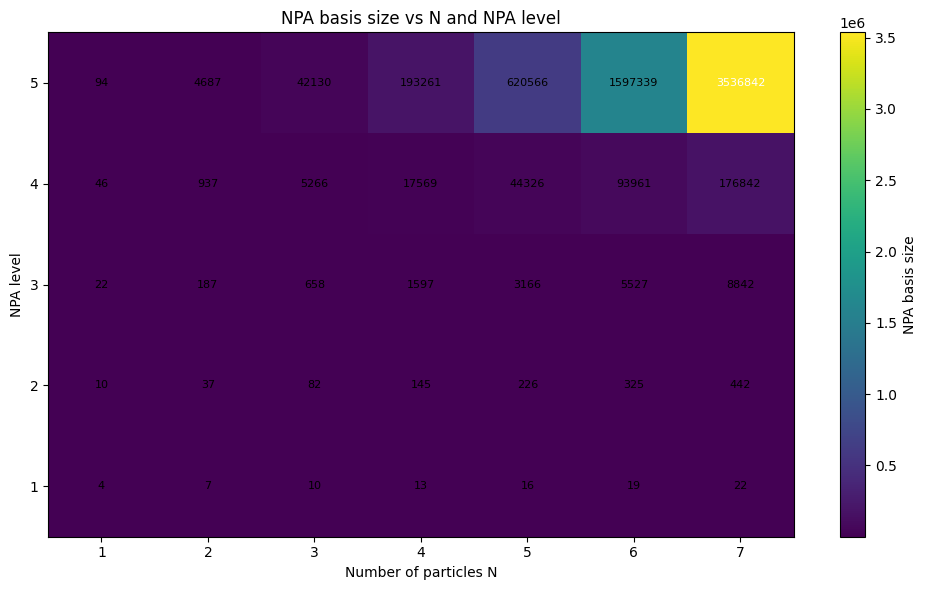

In [4]:
plots.npa_basis_size_heatmap(N=7, max_NPA_level=5)


c:\Users\lmatos\AppData\Local\Programs\Python\Python313\Lib\site-packages\cvxpy\problems\problem.py:164: UserWarning: Constraint #6 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


Computed E_lb/N from function: -0.9999998730608528
Exact E0/N: -1.0


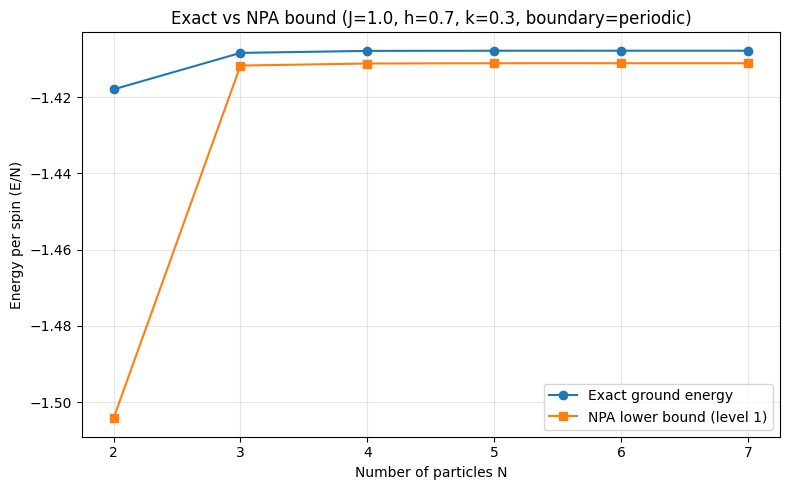

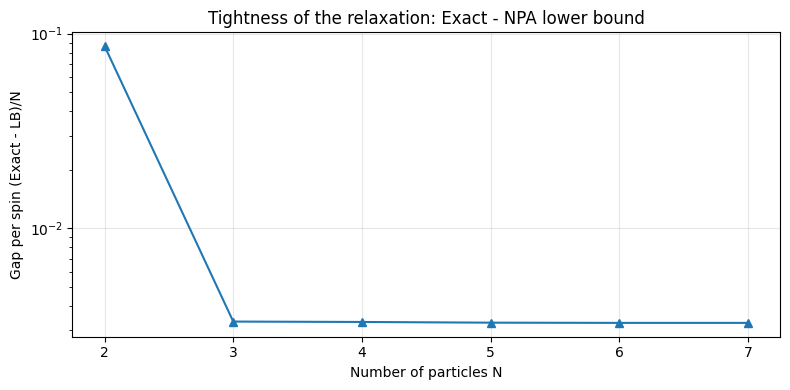

In [32]:
# SDP parameters
NPA_level = 2
N = 2
solver = "SCS" # Look into this later

exact_E = exact_ground_state_eigenpair(H)[0]

E_lb_val = npa_lb_energy(
    J=J, h=h, k=k,
    N=N,
    NPA_level=NPA_level,
    solver=solver,
    boundary=boundary
)

print(f"Computed E_lb/N from function: {E_lb_val/N}")
print(f"Exact E0/N: {exact_E/N}")


Ns, E_exact, E_lb = plots.plot_exact_vs_npa_energy_vs_N(
    N_values=range(2, 8),
    J=1.0, h=0.7, k=0.3,
    NPA_level=1,
    boundary="periodic",
    solver=solver,
    per_site=True
)   

#  Bug/Numerical error somewhere since the NPA lower bound is above the exact energy for some N.


In [ ]:
exact_data = benchmark_exact_diagonalization(
    N_values=range(2, 14),
    J=J, h=h, k=k,
    boundary="periodic",
    repeats=1,
)

In [25]:
npa_data_1 = benchmark_npa_relaxation(
    N_values=range(2, 15),
    NPA_level=1,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="SCS",
    repeats=1,
    scs_eps=1e-6,
    scs_max_iters=20000,
)

c:\Users\lmatos\AppData\Local\Programs\Python\Python313\Lib\site-packages\cvxpy\problems\problem.py:164: UserWarning: Constraint #6 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


In [26]:
npa_data_2 = benchmark_npa_relaxation(
    N_values=range(2, 5),
    NPA_level=2,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="SCS",
    repeats=1,
    scs_eps=1e-6,
    scs_max_iters=20000,
)

c:\Users\lmatos\AppData\Local\Programs\Python\Python313\Lib\site-packages\cvxpy\problems\problem.py:164: UserWarning: Constraint #6 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


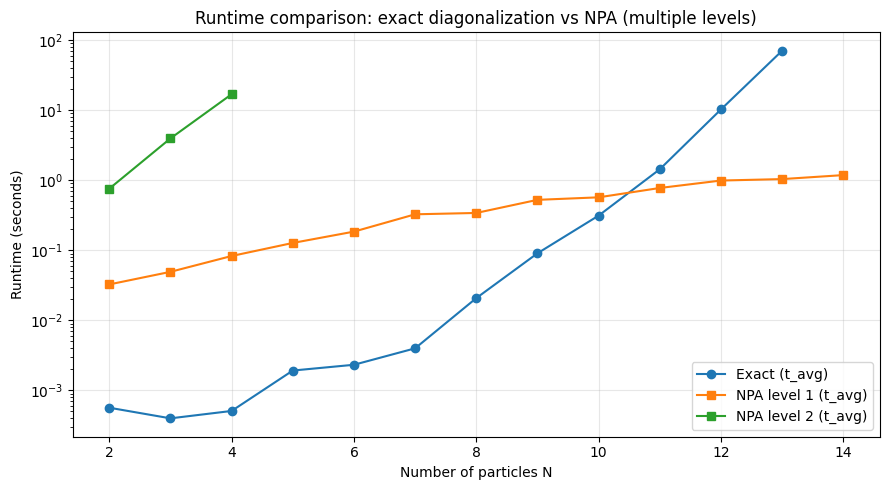

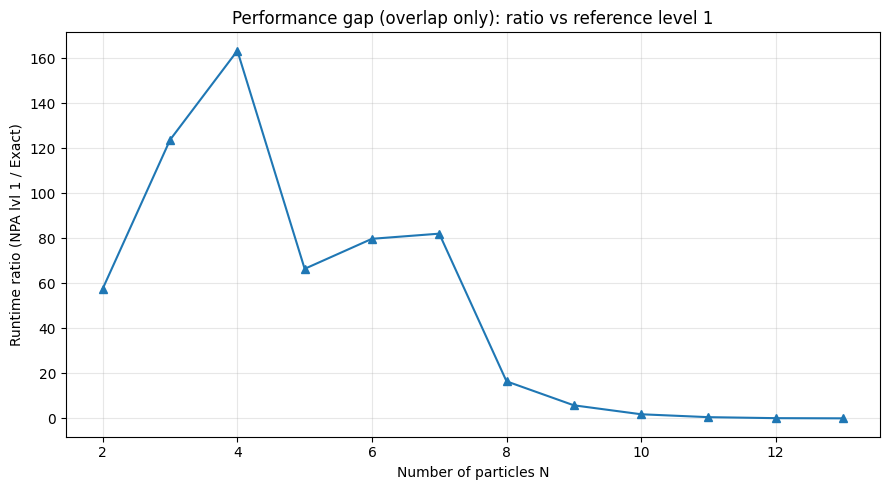

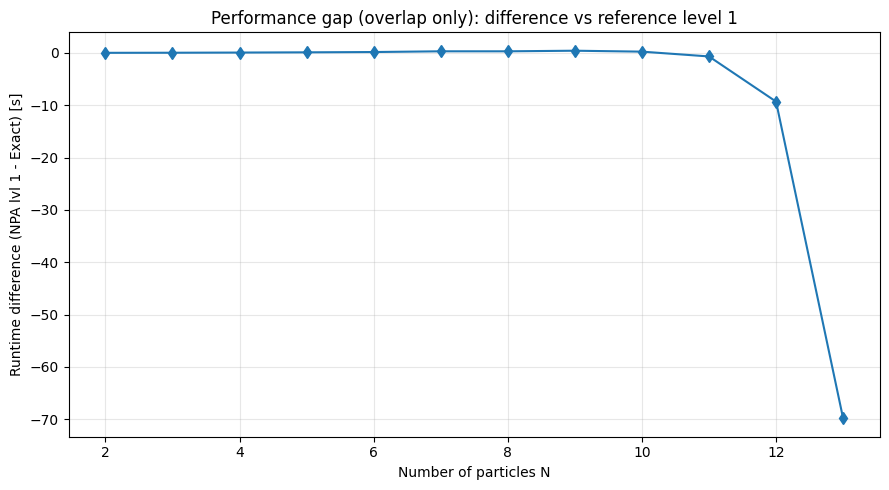

In [35]:
npa_data_by_level = {
    1: npa_data_1,
    2: npa_data_2
}

out = plots.plot_runtime_comparison_multi_levels(
    exact_data=exact_data,
    npa_data_by_level=npa_data_by_level,
    levels=[1,2],
    use="t_avg",
    logy=True,
)